# Этап 1 — Построение графов

**Датасет:** RecipeNLG — `full_dataset.csv` (2.23M рецептов, ~2.2 ГБ)

Строим два графа:
- **Граф I** (`ingredient_graph.graphml`) — ингредиент ↔ ингредиент, вес ребра = число совместных рецептов
- **Граф G** (`bipartite_sample.graphml`) — рецепт ↔ ингредиент (двудольный, 200k рецептов)

Оба используются в этапах 3–5.

In [1]:
import ast
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED      = 42
DATA_PATH = Path('full_dataset.csv')
OUT       = Path('output_graphs')
OUT.mkdir(exist_ok=True)
print('OK')

OK


## 1.1 Подсчёт совместных вхождений ингредиентов

Читаем датасет чанками
Для каждого рецепта обновляем счётчик пар ингредиентов (`cooc`) и частот (`ing_freq`).

In [2]:
cooc     = Counter()   # (ингр_a, ингр_b) → число рецептов
ing_freq = Counter()   # ингр → число рецептов
n_recipes = 0

for chunk in tqdm(pd.read_csv(DATA_PATH, usecols=['NER'], chunksize=100_000),
                  desc='Читаем чанки'):
    for raw in chunk['NER']:
        try:
            ings = list({x.lower().strip() for x in ast.literal_eval(raw) if x.strip()})
        except Exception:
            continue
        n_recipes += 1
        ing_freq.update(ings)
        for a, b in combinations(sorted(ings), 2):
            cooc[(a, b)] += 1

print(f'Рецептов обработано : {n_recipes:,}')
print(f'Уникальных ингр.    : {len(ing_freq):,}')
print(f'Уникальных пар      : {len(cooc):,}')

Читаем чанки: 0it [00:00, ?it/s]

Рецептов обработано : 2,231,142
Уникальных ингр.    : 198,899
Уникальных пар      : 5,981,626


## 1.2 Граф I — ингредиент ↔ ингредиент

Фильтруем редкие ингредиенты (< 50 рецептов) и слабые связи (< 10 совместных).  
К весу рёбер добавляем **PMI** — убираем пары «соль + сахар + smth».

Пороги (50/10) - анализ чувствительности.

In [3]:
MIN_FREQ = 50
MIN_COOC = 10

valid = {ing for ing, cnt in ing_freq.items() if cnt >= MIN_FREQ}
total_pairs = sum(cooc.values())
total_ings  = float(sum(ing_freq.values()))

I = nx.Graph()
I.add_nodes_from(valid)

for (a, b), w in tqdm(cooc.items(), desc='Строим граф I'):
    if a in valid and b in valid and w >= MIN_COOC:
        pab = w / total_pairs
        pa  = ing_freq[a] / total_ings
        pb  = ing_freq[b] / total_ings
        pmi = float(np.log(pab / (pa * pb + 1e-9)))
        I.add_edge(a, b, weight=w, pmi=pmi)

nx.set_node_attributes(I, dict(ing_freq), name='freq')

lcc = max(nx.connected_components(I), key=len)
print(f'Граф I: {I.number_of_nodes():,} узлов, {I.number_of_edges():,} рёбер')
print(f'Плотность: {nx.density(I):.5f}')
print(f'LCC: {len(lcc):,} узлов ({100*len(lcc)/I.number_of_nodes():.1f}%)')

# Топ-10 пар по весу
top_pairs = sorted(I.edges(data=True), key=lambda e: -e[2]['weight'])[:10]
print('\nТоп-10 пар по числу совместных рецептов:')
for a, b, d in top_pairs:
    print(f'  {a:<25} + {b:<25}  {d["weight"]:,}')

Строим граф I:   0%|          | 0/5981626 [00:00<?, ?it/s]

Граф I: 7,199 узлов, 418,645 рёбер
Плотность: 0.01616
LCC: 7,196 узлов (100.0%)

Топ-10 пар по числу совместных рецептов:
  salt                      + flour                      301,582
  salt                      + sugar                      295,046
  flour                     + sugar                      254,634
  butter                    + salt                       252,491
  salt                      + eggs                       231,566
  sugar                     + eggs                       212,938
  salt                      + onion                      211,540
  salt                      + garlic                     206,321
  flour                     + eggs                       197,300
  butter                    + flour                      196,656


## 1.2′ Обоснование порогов: анализ чувствительности

Пересобираем граф на сетке порогов (в памяти, без перечтения датасета) и смотрим, как меняются его свойства: число узлов/рёбер, плотность и покрытие крупнейшей связной компоненты (LCC). 
Цель — показать, что в окрестности выбора результат **устойчив** (выходит на плато), а сам выбор — разумный компромисс между покрытием словаря и зашумлённостью рёбрами.

,MIN_FREQ,MIN_COOC,узлы,рёбра,плотность,LCC %,выбор
0,20,5,12692,745561,0.00926,99.9,
1,20,10,12692,436139,0.00542,94.2,
2,20,20,12692,255220,0.00317,67.2,
3,50,5,7199,688297,0.02657,100.0,
4,50,10,7199,418645,0.01616,100.0,←
5,50,20,7199,252569,0.00975,97.0,
6,100,5,4761,624273,0.05509,100.0,
7,100,10,4761,393317,0.03471,100.0,
8,100,20,4761,244079,0.02154,99.8,
9,200,5,3145,539738,0.10917,100.0,


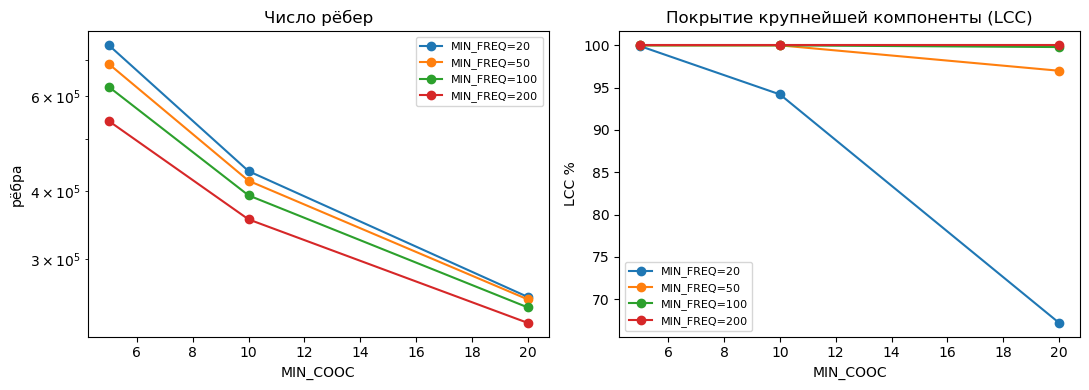

In [4]:
# === Анализ чувствительности порогов MIN_FREQ × MIN_COOC ===
# Пересборка графа на сетке (в памяти, через numpy-маски — быстро, без перечтения CSV).
keys = list(cooc.keys())
w_arr = np.fromiter((cooc[k] for k in keys), dtype=np.int64, count=len(keys))
fa = np.fromiter((ing_freq[k[0]] for k in keys), dtype=np.int64, count=len(keys))
fb = np.fromiter((ing_freq[k[1]] for k in keys), dtype=np.int64, count=len(keys))

freq_grid = [20, 50, 100, 200]
cooc_grid = [5, 10, 20]

rows = []
for mf in freq_grid:
    valid = {ing for ing, c in ing_freq.items() if c >= mf}
    for mc in cooc_grid:
        mask = (w_arr >= mc) & (fa >= mf) & (fb >= mf)
        edges = [keys[idx] for idx in np.nonzero(mask)[0]]
        G = nx.Graph(); G.add_nodes_from(valid); G.add_edges_from(edges)
        n, e = G.number_of_nodes(), G.number_of_edges()
        lcc = len(max(nx.connected_components(G), key=len)) if e else 0
        rows.append({'MIN_FREQ': mf, 'MIN_COOC': mc, 'узлы': n, 'рёбра': e,
                     'плотность': round(nx.density(G), 5),
                     'LCC %': round(100 * lcc / n, 1) if n else 0.0,
                     'выбор': '←' if (mf, mc) == (MIN_FREQ, MIN_COOC) else ''})
sens = pd.DataFrame(rows)
display(sens)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for mf in freq_grid:
    sub = sens[sens['MIN_FREQ'] == mf]
    ax[0].plot(sub['MIN_COOC'], sub['рёбра'], marker='o', label=f'MIN_FREQ={mf}')
    ax[1].plot(sub['MIN_COOC'], sub['LCC %'], marker='o', label=f'MIN_FREQ={mf}')
ax[0].set(xlabel='MIN_COOC', ylabel='рёбра', title='Число рёбер'); ax[0].set_yscale('log'); ax[0].legend(fontsize=8)
ax[1].set(xlabel='MIN_COOC', ylabel='LCC %', title='Покрытие крупнейшей компоненты (LCC)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / 'threshold_sensitivity.png', dpi=120); plt.show()

## 1.3 Граф G — рецепт ↔ ингредиент (двудольный)

Берём 200k рецептов — полный граф (~2M рецептов) требует 8–10 ГБ RAM.

In [5]:
SAMPLE = 200_000

df_bip = pd.read_csv(DATA_PATH, nrows=SAMPLE, usecols=['title', 'NER'])
df_bip['ner_list'] = df_bip['NER'].apply(ast.literal_eval)

G = nx.Graph()
for idx, row in tqdm(df_bip.iterrows(), total=SAMPLE, desc='Строим граф G'):
    rid = f'recipe::{idx}'
    G.add_node(rid, ntype='recipe', title=row['title'])
    for ing in row['ner_list']:
        name = ing.lower().strip()
        if name:
            G.add_node(name, ntype='ingredient', freq=ing_freq.get(name, 0))
            G.add_edge(rid, name)

r_nodes = [n for n, d in G.nodes(data=True) if d.get('ntype') == 'recipe']
i_nodes = [n for n, d in G.nodes(data=True) if d.get('ntype') == 'ingredient']

print(f'Граф G: {len(r_nodes):,} рецептов, {len(i_nodes):,} ингредиентов, {G.number_of_edges():,} рёбер')
print(f'Двудольный: {nx.is_bipartite(G)}')

Строим граф G:   0%|          | 0/200000 [00:00<?, ?it/s]

Граф G: 200,000 рецептов, 22,534 ингредиентов, 1,449,174 рёбер
Двудольный: True


## 1.4 Визуализация: степени и эго-граф

Распределение степеней в графе I + эго-граф вокруг 'garlic' (ближайшие соседи).

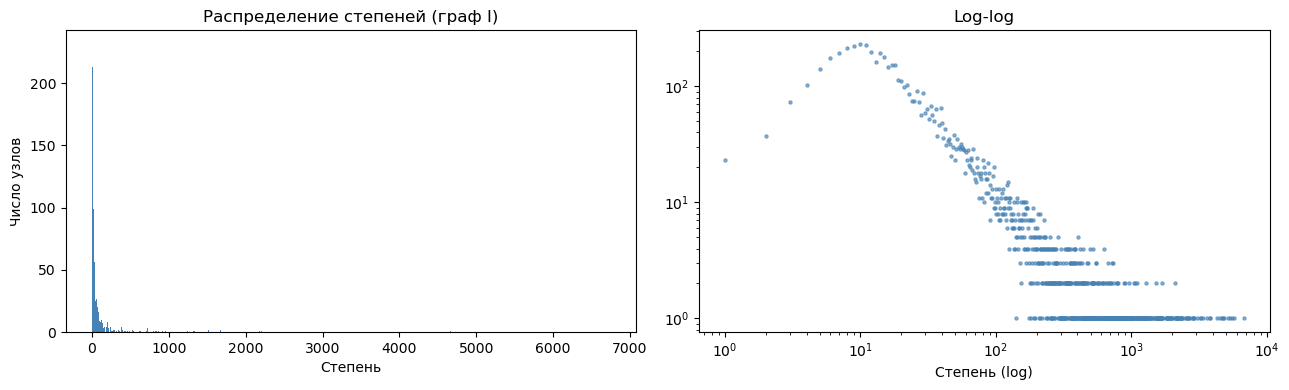

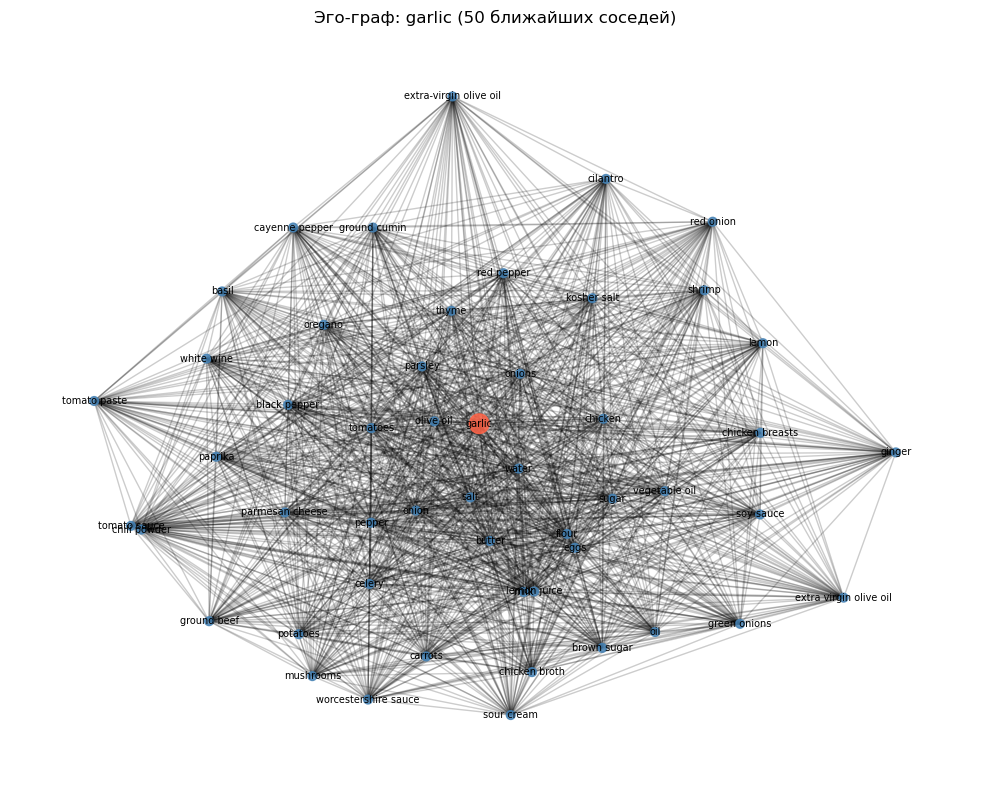

In [6]:
deg_vals = [d for _, d in I.degree()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Распределение степеней (линейная + log-log)
dd = Counter(deg_vals)
xs = sorted(dd)
ys = [dd[x] for x in xs]
axes[0].bar(xs, ys, color='steelblue', width=1)
axes[0].set(xlabel='Степень', ylabel='Число узлов', title='Распределение степеней (граф I)')

axes[1].scatter(xs, ys, s=5, alpha=0.6, color='steelblue')
axes[1].set(xscale='log', yscale='log', xlabel='Степень (log)', title='Log-log')

plt.tight_layout()
plt.savefig(OUT / 'degree_distribution.png', dpi=120)
plt.show()

# Эго-граф (берём самый частый ингредиент, если garlic не в графе)
center = 'garlic' if 'garlic' in I else max(I.nodes(), key=lambda n: I.degree(n))
top_nbrs = sorted(I.neighbors(center), key=lambda n: I[center][n]['weight'], reverse=True)[:50]
ego = I.subgraph([center] + top_nbrs).copy()

pos    = nx.spring_layout(ego, seed=SEED, k=0.9)
sizes  = [200 if n == center else 40 for n in ego.nodes]
colors = ['tomato' if n == center else 'steelblue' for n in ego.nodes]

fig2, ax2 = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(ego, pos, node_size=sizes, node_color=colors, alpha=0.85, ax=ax2)
nx.draw_networkx_edges(ego, pos, alpha=0.2, ax=ax2)
nx.draw_networkx_labels(ego, pos, font_size=7, ax=ax2)
ax2.set_title(f'Эго-граф: {center} (50 ближайших соседей)')
ax2.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'ego_garlic.png', dpi=120)
plt.show()

## 1.5 Сохранение

In [7]:
nx.write_graphml(I, OUT / 'ingredient_graph.graphml')
nx.write_graphml(G, OUT / 'bipartite_sample.graphml')

pd.DataFrame(
    [(ing, cnt) for ing, cnt in ing_freq.items()],
    columns=['ingredient', 'freq']
).sort_values('freq', ascending=False).to_csv(OUT / 'ingredient_freq.csv', index=False)

print('Сохранено:')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name:<35} {f.stat().st_size/1e6:.1f} МБ')

Сохранено:
  bipartite_sample.graphml            107.6 МБ
  chem_embs.pkl                       15.1 МБ
  cooc.pkl                            130.7 МБ
  cuisine_communities.png             0.0 МБ
  cuisine_confusion.png               0.0 МБ
  cuisine_model_comparison.png        0.0 МБ
  cuisine_tsne.png                    0.2 МБ
  cuisine_tsne_emb.png                0.5 МБ
  cuisine_tsne_joint.png              0.5 МБ
  degree_distribution.png             0.0 МБ
  dish_validity.png                   0.1 МБ
  dish_validity_all_models.png        0.0 МБ
  dish_validity_compare.png           0.0 МБ
  ego_garlic.png                      0.9 МБ
  graphsage_model.pt                  0.2 МБ
  ing_freq.pkl                        4.4 МБ
  ingredient_communities.json         0.1 МБ
  ingredient_embeddings.npz           1.8 МБ
  ingredient_freq.csv                 4.0 МБ
  ingredient_graph.graphml            60.4 МБ
  link_prediction_comparison.csv      0.0 МБ
  link_prediction_comparison.png      